# Tohoku Source Notebook

## Setup Environment

We assume you have installed `anuga` in your `python` environment. 

Some gauge data from  https://www.ngdc.noaa.gov/hazard/dart/2011honshu_dart.html and 
described in NOAA paper https://doi.org/10.1080/19475705.2011.632443. Also data is available from https://github.com/rjleveque/tohoku2011-paper1



### Setup inline graphics and animation

In [1]:
import os
import anuga
import numpy as np
import matplotlib.pyplot as plt
import utm
import okada_kl_subfaults as okl
#from google.colab import files

%matplotlib inline
%load_ext autoreload
%autoreload 2
#%load_ext memory_profiler

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

## Tohoku Folder

Change into the Tohoku folder (if you have not done that already)

In [2]:
try:
    os.chdir('Tohoku')
except:
    pass
print(f'Current directory {os.getcwd()}')



class Gauge:

    def __init__(self, long, lat, t1=0.0, t2= 1.e10):

        self.lat  = lat
        self.long = long

        self.t1 = t1
        self.t2 = t2

        import utm

        east, north, zone_no, zone_letter =  utm.from_latlon(self.lat, self.long, force_zone_number=54)

        self.east = east
        self.north = north
        self.zone_no = zone_no
        self.zone_letter = zone_letter


gauges = {}

# location of dart buoys
gauges[21401] =  Gauge(152.583, 42.617, t1 = 1800.)
gauges[21413] =  Gauge(152.1167, 30.5153, t1 = 1800.)
#gauges[21414] = [178.281, 48.938,  1800., 1.e10]
#gauges[21415] = [171.849, 50.183,  1800., 1.e10]
#gauges[21416] = [163.505, 48.052,  1800., 1.e10]
gauges[21418] =  Gauge(148.694, 38.711)
gauges[21419] =  Gauge(155.736, 44.455,  t1 = 1800.)
#gauges[51407] = [203.484, 19.642, 22000., 1.e10]
#gauges[52402] = [154.116, 11.883, 10000., 1.e10]

# location of integation points
gauges[0] = Gauge(141.0,38.0)
gauges[1] = Gauge(141.0,38.125)
gauges[2] = Gauge(141.0,38.25)



Current directory /home/steve/Tohoku


### Fault Parameters

In [3]:
# location of epicentre (absolute coordinates)
#x0 = 300000.0
#y0 = 250000.0
x0 = 720000.0
y0 = 4200000.0

km = 1000.0

# parameters of fault
parameters_small = dict(
    depth=15*km,
    length=100*km,
    width=30*km,
    strike=190.0,
    dip=15.0,
    rake=90.0,
    slip=30.0,
    opening=0.0,
    nu=0.25,
)


parameters = dict(
    depth=20*km,
    length=200*km,
    width=50*km,
    strike=195.0,
    dip=14.0,
    rake=87.0,
    slip=35.0,
    opening=0.0,
    nu=0.25,
)



In [4]:
# setup KL field and sampling method

In [5]:
# draw a sample from the generating method
# create associated deformation

# new deformations Uz will be possible by just running this cell again

## Setup Anuga Model

### Project parameters

In [6]:
import project


Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 50000000                 88753.41           1775
Interior 12000000                 30241.19           2520
Interior 2000000                  11288.13           5644
Bounding 50000000                 371317.27          7426
Estimated total number of triangles: 24807
Number of triangles: 24807
output directory: /home/steve/Tohoku/_output_Caltech
source directory: /home/steve/Tohoku/sources/Caltech.pts
Note: This is generally about 20% less than the final amount


project name:  Tohoku
Number of triangles =  26587
The extent is  (np.float64(0.0), np.float64(880000.0), np.float64(0.0), np.float64(570000.0))
Geo reference is  (zone=54, easting=420000.000000, northing=3950000.000000, hemisphere=northern, epsg=32654)


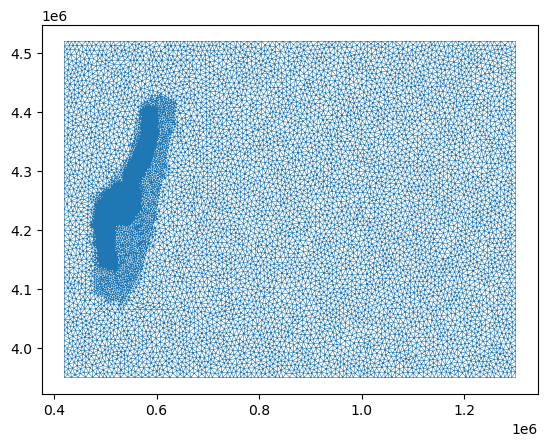

In [8]:
print ('project name: ', project.name_stem)
domain = anuga.create_domain_from_regions(project.bounding_polygon,
                                        boundary_tags={'bottom': [0],
                                                       'ocean_east': [1],
                                                       'top': [2],
                                                       'onshore': [3]},
                                        maximum_triangle_area=project.res_whole,
                                        #mesh_filename=project.meshname,
                                        interior_regions=project.interior_regions,
                                        use_cache=False,
                                        verbose=False)



domain.set_hemisphere('northern')
domain.set_zone(54)
xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner
print ('Number of triangles = ', len(domain))
print ('The extent is ', domain.get_extent())
print ('Geo reference is ',domain.geo_reference)

domain.set_quantity('elevation',
                        filename=project.name_stem + '.pts',
                        use_cache=True,
                        verbose=False,
                        alpha=0.1)

domain.set_name('tohoku_source_example')


#tide = -0.45
tide = 0.0
domain.set_quantity('stage', tide)


Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values

Stage[:] = np.maximum(Elevation, Stage)
                        

dplotter = anuga.Domain_plotter(domain, absolute=True)
plt.triplot(dplotter.triang, linewidth = 0.4);
#print (domain.statistics())

#domain.set_quantity('elevation', function=topography, location='centroids')

### View Elevation

Text(0.5, 1.0, 'Elevation (Bathymetry) east coast Japan')

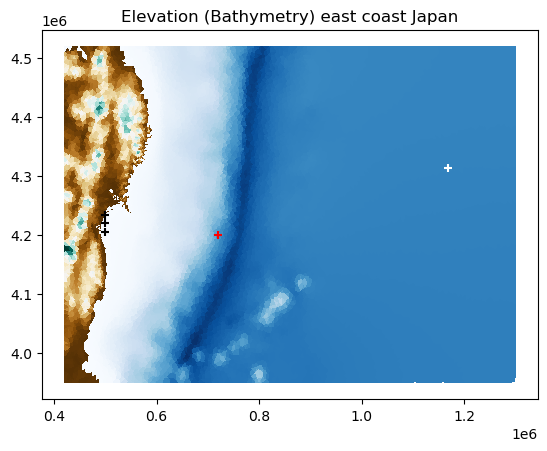

In [10]:
import cartopy
import cartopy.crs as ccrs

fig = plt.figure()
#ax = fig.add_subplot(111, projection=ccrs.UTM(zone=54))
ax = fig.add_subplot(111)

# Test for dry areas
md = 0.01

# Dry areas
dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang,
                      facecolors=dplotter.elev,
                      cmap='BrBG')
                      #cmap='viridis_r')
                      #cmap='Greys_r')

# Wet Areas
dplotter.triang.set_mask(dplotter.depth <= md)
ax.tripcolor(dplotter.triang,
                      facecolors=dplotter.elev,
                      cmap='Blues_r')
                      #cmap='viridis')
                      #vmin=vmin, vmax=vmax)

dplotter.triang.set_mask(None)

# plot epicentre (absolute)

ax.scatter(x0, y0, marker='+', color='r')

# dart 21418 location 
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w')

# locations on coast
ax.scatter(gauges[0].east, gauges[0].north, marker='+', color='k')
ax.scatter(gauges[1].east, gauges[1].north, marker='+', color='k')
ax.scatter(gauges[2].east, gauges[2].north, marker='+', color='k')

# for gauge_no, gauge_data in gauges.items():
#     print(gauge_no, gauge_data.east, gauge_data.north)
#     ax.scatter(gauge_data.east, gauge_data.north, marker='+', color='r')

# plot dart location



#ax.set_extent([450000,2000000,4000000, 4400000], crs=ccrs.UTM(zone=54))
#gridlines = ax.gridlines(draw_labels=True)

#ax.coastlines()

plt.title('Elevation (Bathymetry) east coast Japan')

#plt.colorbar()



### Apply deformation to Stage and Elevation

In [11]:
# we need to come up with a way to generate difference samples when running the notebook a second time. 
# Need a loop to generate the samples and then run the simulation for each sample.


#sample = 'random'
sample = 'sobol'
#sample = None

if sample == 'random' or sample == 'sobol':
    import okada

    x = domain.centroid_coordinates[:,0]
    y = domain.centroid_coordinates[:,1]

    uE,uN,uZ, _ = okl.kl_deformation(x, y, xoff=x0-xll, yoff=y0-yll, E_subfault=10, N_subfault=10, 
                                     sample=sample, iseed=1234, **parameters)

    Elevation = domain.quantities['elevation'].centroid_values
    Stage     = domain.quantities['stage'].centroid_values

    print ('Stage extent     ',np.max(dplotter.stage), np.min(dplotter.stage))

    Elevation[:] = Elevation + uZ
    Stage[:]     = Stage + uZ

    print ('uZ extent        ',np.max(uZ), np.min(uZ))


else : # Use one of precomputed source files
    domain.add_quantity('stage',
                        filename=project.source_file,
                        use_cache=True,
                        verbose=False)



dplotter = anuga.Domain_plotter(domain, absolute=True)

print ('Stage extent     ',np.max(dplotter.stage), np.min(dplotter.stage))
print ('Elevation extent ',np.max(dplotter.elev), np.min(dplotter.elev))
print ('Depth extent     ',np.max(dplotter.depth), np.min(dplotter.depth))

Stage extent      1386.5451575209129 0.0
uZ extent         13.44305963330086 -6.006125170858666
Stage extent      1386.5598393860416 -6.006125170858666
Elevation extent  1386.5598393860416 -7861.424153722189
Depth extent      7861.307026198032 0.0


### View Stage after source has been applied

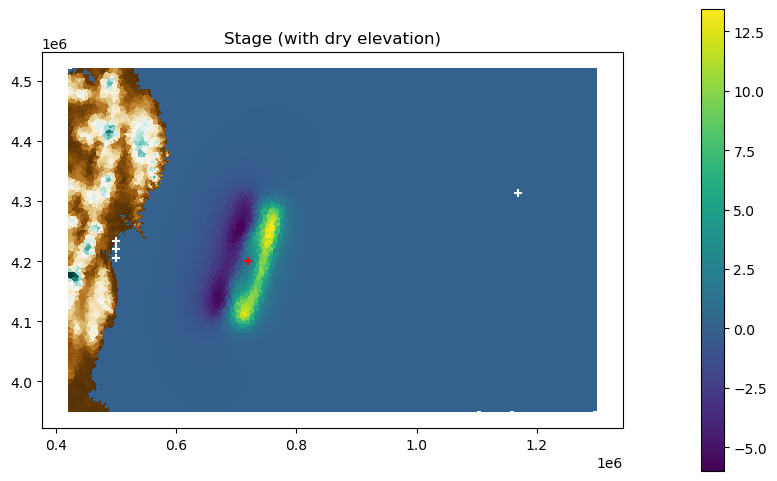

In [12]:
# plt the updated elevation and stage
fig = plt.figure(figsize=(10,10))
#ax = fig.add_subplot(111, projection=ccrs.UTM(zone=54))
ax = fig.add_subplot(111)

md = 0.01

# dry areas
dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang,
                      facecolors=dplotter.elev,
                      cmap='BrBG')
                      #cmap='viridis_r')
                      #cmap='Greys_r')


# wet areas
dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang,
                      facecolors=dplotter.stage,
                      #cmap='Blues_r')
                      cmap='viridis')
                      #vmin=vmin, vmax=vmax)

ax.set_aspect('equal', adjustable='box')

#fig.colorbar(img, pad = 0.2, shrink=0.6)
fig.colorbar(img, ax=ax, orientation='vertical', pad = 0.1, shrink=0.6)

ax.scatter(x0,y0,marker='+', color='r')

ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w')
ax.scatter(gauges[0].east, gauges[0].north, marker='+', color='w')
ax.scatter(gauges[1].east, gauges[1].north, marker='+', color='w')
ax.scatter(gauges[2].east, gauges[2].north, marker='+', color='w')

#ax.set_extent([400000,2500000,4000000, 4400000], crs=ccrs.UTM(zone=54))
#gridlines = ax.gridlines(draw_labels=True)



#ax.coastlines()

plt.title('Stage (with dry elevation)');

### Setup Boundary Conditions

In [13]:
Br = anuga.Reflective_boundary(domain)
Bf = anuga.Flather_external_stage_zero_velocity_boundary(domain,lambda t :tide)
# Boundary conditions
domain.set_boundary({'onshore': Br,
                         'bottom': Bf,
                         'ocean_east': Bf,
                         'top': Bf})

                         

### Setup max min collection

In [14]:
from anuga.operators.collect_max_quantities_operator import Collect_max_quantities_operator

max_min_collector = Collect_max_quantities_operator(domain)


### Evolve the simulation

In [15]:
import time
t0 = time.time()
min = 60.
hour = 3600.

dplotter = anuga.Domain_plotter(domain, absolute=True)

tid_21418 = domain.get_triangle_containing_point([gauges[21418].east, gauges[21418].north])
gauge_21418_stage = []

tid_0 = domain.get_triangle_containing_point([gauges[0].east, gauges[0].north])
gauge_0_stage = []

tid_1 = domain.get_triangle_containing_point([gauges[1].east, gauges[1].north])
gauge_1_stage = []

tid_2 = domain.get_triangle_containing_point([gauges[2].east, gauges[2].north])
gauge_2_stage = []

gauge_time = []

# Initial run without any event
for t in domain.evolve(yieldstep=2*min, finaltime=2.0*hour):

    gauge_21418_stage.append(dplotter.stage[tid_21418])
    gauge_0_stage.append(dplotter.stage[tid_0])
    gauge_1_stage.append(dplotter.stage[tid_1])
    gauge_2_stage.append(dplotter.stage[tid_2])
    gauge_time.append(t)


    #dplotter.save_stage_frame(vmin=-2.0,vmax=14.0)

    domain.print_timestepping_statistics()

print ('That took %.2f seconds' %(time.time()-t0))


Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=340MB
Time = 120.0000 (sec), delta t in [4.05013167, 4.05189722] (s), steps=30 (0s), elapsed (0s), eta (21s), mem=341MB
Time = 240.0000 (sec), delta t in [4.05146998, 4.05321346] (s), steps=30 (0s), elapsed (0s), eta (19s), mem=341MB
Time = 360.0000 (sec), delta t in [4.05284613, 4.05297049] (s), steps=30 (0s), elapsed (0s), eta (18s), mem=341MB
Time = 480.0000 (sec), delta t in [4.05289854, 4.05299419] (s), steps=30 (0s), elapsed (1s), eta (17s), mem=341MB
Time = 600.0000 (sec), delta t in [4.05290938, 4.05301522] (s), steps=30 (0s), elapsed (1s), eta (17s), mem=341MB
Time = 720.0000 (sec), delta t in [4.05291537, 4.05299861] (s), steps=30 (0s), elapsed (1s), eta (16s), mem=341MB
Time = 840.0000 (sec), delta t in [4.05300063, 4.05313886] (s), steps=30 (0s), elapsed (2s), eta (16s), mem=341MB
Time = 960.0000 (sec), delta t in [4.05314207, 4.05321689] (s), steps=30 (0s), elapsed (2s), eta (16s), mem=341MB
Time = 1080.0000 (s

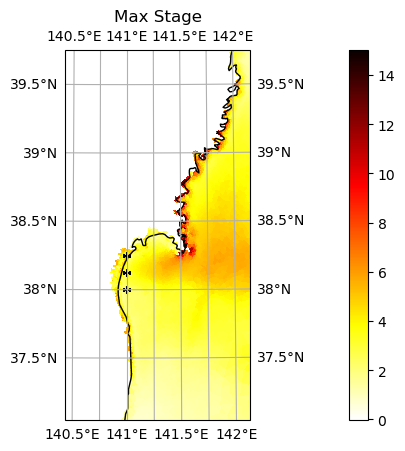

In [16]:
max_depth = max_min_collector.max_depth
max_stage = max_min_collector.max_stage

wet_mask = max_depth >= 0.01

wet_max_stage = np.where(max_depth >= 0.01, max_stage, np.nan)

fig = plt.figure()
ax = fig.add_subplot(111, projection=ccrs.UTM(zone=54))
#ax = fig.add_subplot(111)



img = ax.tripcolor(dplotter.triang,
                      facecolors=wet_max_stage,
                      #cmap='BrBG')
                      #cmap='viridis_r')
                      cmap='hot_r',
                      vmax=15.0)
                      #cmap='Greys_r')


# plot epicentre (absolute)
x0 = 720000.0
y0 = 4200000.0
ax.scatter(x0, y0, marker='+', color='r')

# dart 21418 location 
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w')

# locations on coast
ax.scatter(gauges[0].east, gauges[0].north, marker='+', color='k')
ax.scatter(gauges[1].east, gauges[1].north, marker='+', color='k')
ax.scatter(gauges[2].east, gauges[2].north, marker='+', color='k')




ax.set_extent([450000,600000,4100000, 4400000], crs=ccrs.UTM(zone=54))
gridlines = ax.gridlines(draw_labels=True)

ax.coastlines()

plt.title('Max Stage')
plt.colorbar(img, pad = 0.2, shrink=1.0)



In [17]:
#dplotter.make_stage_animation()

Text(0.5, 1.0, 'Stage at gauges')

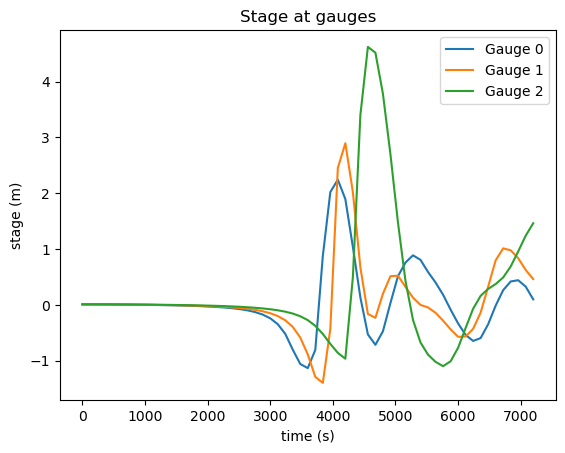

In [18]:
t = np.array(gauge_time)
stage_21418 = np.array(gauge_21418_stage)
stage_0 = np.array(gauge_0_stage)
stage_1 = np.array(gauge_1_stage)
stage_2 = np.array(gauge_2_stage)


#plt.plot(t, stage_21418)
plt.plot(t, stage_0, label='Gauge 0')
plt.plot(t, stage_1, label='Gauge 1')
plt.plot(t, stage_2, label='Gauge 2')
plt.xlabel('time (s)')
plt.ylabel('stage (m)')  
plt.legend()
plt.title('Stage at gauges')

Text(0.5, 1.0, 'Comparison with 21418 data')

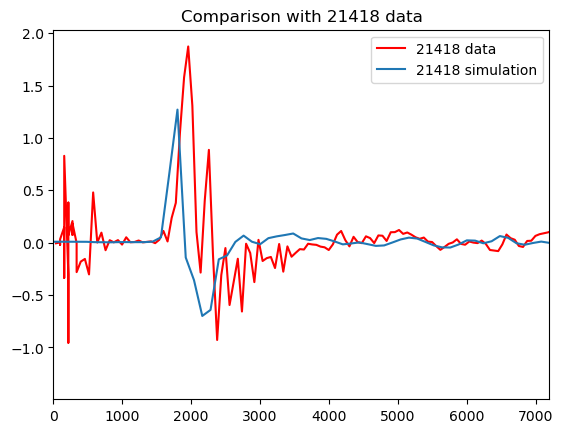

In [53]:
xy = np.loadtxt('21418_notide.txt')

plt.plot(xy[:,0], xy[:,1], 'r', label='21418 data') 
plt.plot(t, stage_21418, label='21418 simulation')
plt.legend()
plt.xlim(0, 2*hour)
plt.title('Comparison with 21418 data')

In [16]:
# splotter = anuga.SWW_plotter('tohoku_source_example.sww')

# wet_mask = splotter.depth >= 0.01

# wet_stage = np.where(splotter.depth >= 0.01, splotter.stage, np.nan)

# wet_max_stage = np.nanmax(wet_stage, axis=0)

# wet_max_stage.shape


In [17]:
# fig = plt.figure()
# ax = fig.add_subplot(111, projection=ccrs.UTM(zone=54))
# #ax = fig.add_subplot(111)



# img = ax.tripcolor(dplotter.triang,
#                       facecolors=wet_max_stage,
#                       #cmap='BrBG')
#                       cmap='hot_r')
#                       #cmap='viridis_r')
#                       #cmap='Greys_r')


# # plot epicentre (absolute)
# x0 = 720000.0
# y0 = 4200000.0
# ax.scatter(x0, y0, marker='+', color='r')

# # dart 21418 location 
# ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w')

# # location on coast
# ax.scatter(gauges[0].east, gauges[0].north, marker='+', color='b')

# ax.scatter(gauges[1].east, gauges[1].north, marker='+', color='k')




# #ax.set_extent([450000,2000000,4000000, 4400000], crs=ccrs.UTM(zone=54))
# gridlines = ax.gridlines(draw_labels=True)

# #ax.coastlines()

# plt.title('Max Wet Stage')

# plt.colorbar(img, pad = 0.2, shrink=0.64)


In [21]:

from scipy.stats import qmc
N = 100
sobol_sampler = qmc.Sobol(d=N, scramble=True, seed=None)
z = (sobol_sampler.random()).reshape((N,1))

In [22]:
z.shape

(100, 1)